# CREATE ML-MODEL

## LOAD DATA

In [1]:
import os
import pandas as pd
import duckdb
import seaborn as sns
import matplotlib.pyplot as plt
from functions import choose_features_target
from sklearn.model_selection import TimeSeriesSplit

os.chdir("/Users/jakoberhard/Library/CloudStorage/GoogleDrive-jakanterh@gmail.com/My Drive/uni/python/TBA_project")

con = duckdb.connect("data/train.duckdb")

con.execute("""
CREATE OR REPLACE TABLE train_delay AS
            SELECT * FROM
            read_parquet('data/train_delay_with_features.parquet')
            """)

df_features = con.execute("SELECT * FROM train_delay").fetchdf()

## FEATURE SELECTION

### CHECK HIGH-DIMENSIONAL FEATURES

In [ ]:
# train name
result = df_features.groupby("train_name")["ride_id"].nunique()
print(result.describe(), "\n")

# station name
result = df_features.groupby("station_current")["ride_id"].nunique()
print(result.describe())

count    1340.000000
mean      149.368657
std       166.633171
min         1.000000
25%        16.000000
50%        55.000000
75%       318.000000
max       525.000000
Name: ride_id, dtype: float64 

count      299.000000
mean      6161.414716
std      13631.453819
min          1.000000
25%        164.000000
50%        389.000000
75%       1820.500000
max      76957.000000
Name: ride_id, dtype: float64


: 

: 

These features should not be hot-encoded because the number of dimensions would explode then. Simple target encoding does not work because of the time-dependence. Therefore, historical averages are computed per station and train (name).

Station_start and station_dest were also deleted out of this reason.

### CHECK CORRELATIONS

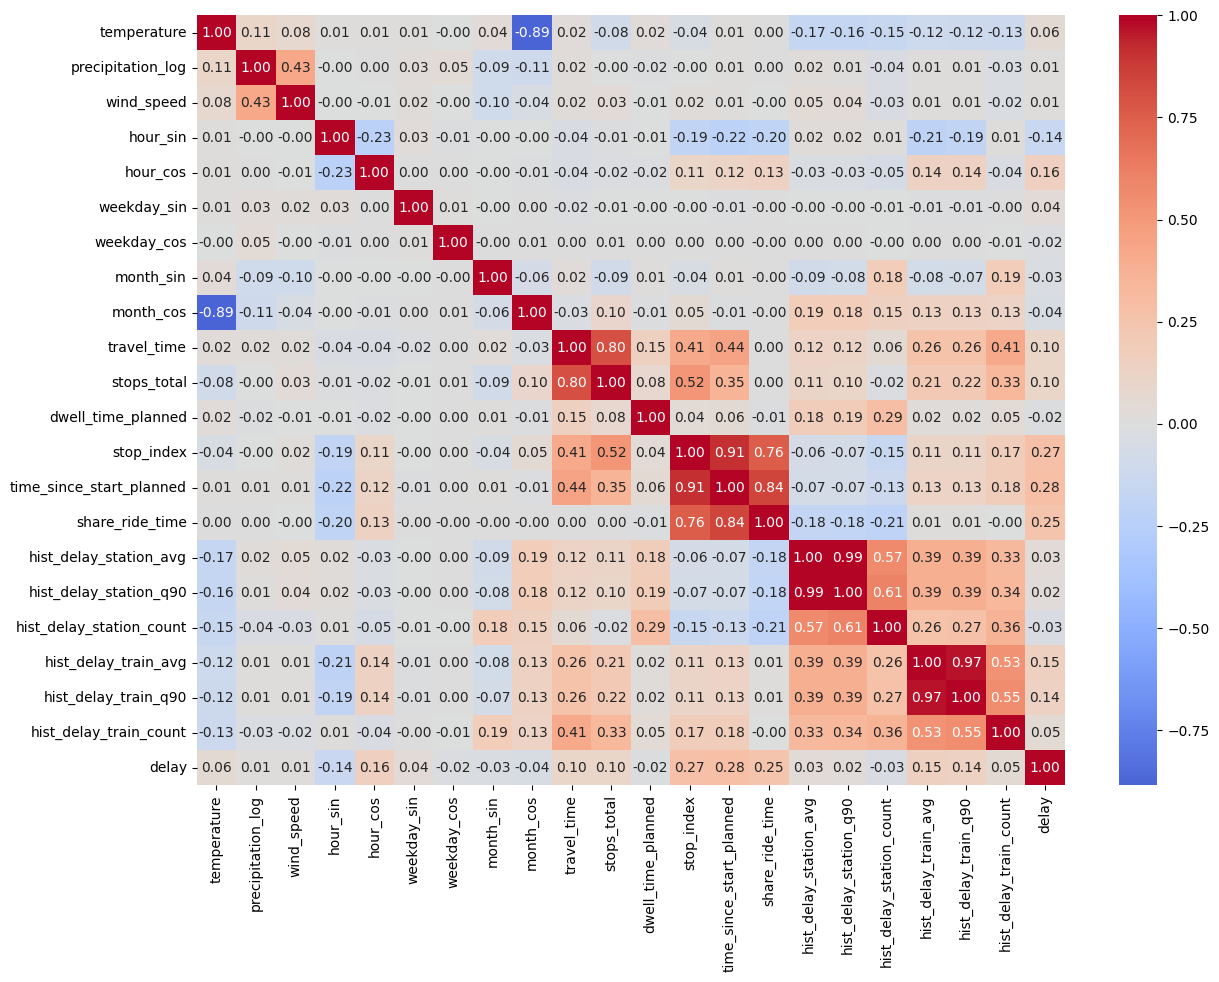

: 

: 

In [ ]:
cols = [
    "temperature", "precipitation_log", "wind_speed",
    "hour_sin", "hour_cos", "weekday_sin", "weekday_cos",
    "month_sin", "month_cos",
    "travel_time", "stops_total", "dwell_time_planned",
    "stop_index", "time_since_start_planned", "share_ride_time",
    "hist_delay_station_avg", "hist_delay_station_q90", "hist_delay_station_count",
    "hist_delay_train_avg", "hist_delay_train_q90", "hist_delay_train_count",
    "delay"
]

df_corr_matrix = df_features[cols]

# compute correlation matrix
corr_matrix = df_corr_matrix.corr()

# visualize 
plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, annot = True, fmt = ".2f", cmap = "coolwarm", center = 0)
plt.show()

Decision on features:
- Drop stop_index and share_ride_time, heavily correlated with time_since_start_planned and have lower correlation with target
- Drop historical q90 info: highly correlated with avg and has lower correlation with target
- Drop stops_total: contains basically travel_time

## PREPROCESSING

In [4]:
# separate features and target
X, y = choose_features_target(df_features)

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# define features groups
feature_scheme = {
    "categorical_one_hot": [
        "train_type", "station_role" # low number of dimensions (hot encoding ok)
    ],
    "numeric_scaled": [
        "temperature", "precipitation_log", "wind_speed", 
        "hour_sin", "hour_cos", "weekday_sin", "weekday_cos", 
        "month_sin", "month_cos", "travel_time", "dwell_time_planned", 
        "time_since_start_planned",
        "hist_delay_station_avg", "hist_delay_station_count",
        "hist_delay_train_avg", "hist_delay_train_count"
    ],
    "binary_passthrough": [
        "precipitation_any", "feast", "weekend", 
        "departure_rush_morning", "departure_rush_evening"
    ]
}


### PREPROCESSOR ###

preprocessor = ColumnTransformer(
    transformers=[

        # categories: one-hot 
        ("cat", OneHotEncoder(handle_unknown = "ignore", sparse_output = False), feature_scheme["categorical_one_hot"]),
        # numeric variables: standard scaling
        ("num", StandardScaler(), feature_scheme["numeric_scaled"]),
        # binary variables: do nothing
        ("pass", "passthrough", feature_scheme["binary_passthrough"])
    ],
    # drop rest
    remainder = "drop")

## CROSS-VALIDATION

In [48]:
### DETERMINE GAP BETWEEN FOLDS

# get count of total observed hours and rows per hour (average)
total_hours = (df_features["departure_real"].max() - df_features["arrival_real"].min()).total_seconds() / 3600
rows_per_hour = len(df_features) / total_hours

# define number of hours that should be in between of folds
min_hours = 5

# calculate gap: rows per hour times gap
recommended_gap = int(rows_per_hour * min_hours)

print(f"Rows per hour: {rows_per_hour:.1f}")
print(f"Recommended minimal gap: {recommended_gap}")

Rows per hour: 139.8
Recommended minimal gap: 699


In [49]:
# define time series cross-validator
ts_cv = TimeSeriesSplit(
    n_splits = 5,
    # lets be conservative: 
    # in very busy times, lower gap number might cause problems
    gap = 1000
)

## TUNING THE MODELS

In [ ]:
# select last 300.000 observations for tuning
n = 300000

X_tune = X.iloc[-n:]
y_tune = y.iloc[-n:]

## PIPELINE


In [ ]:
# build pipelines for all models 


from sklearn_quantile import RandomForestQuantileRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.pipeline import make_pipeline



pipe_rf = make_pipeline(
    preprocessor,
    RandomForestQuantileRegressor(
        random_state = 42,
        q=[0.05, 0.5, 0.95], 
    )
)

pipe_hgb_mean = make_pipeline(
    preprocessor,
    HistGradientBoostingRegressor(
        loss = "squared_error",
        random_state = 42,
    )
)

pipe_hgb_q05 = make_pipeline(
    preprocessor,
    HistGradientBoostingRegressor(
        loss = "quantile",
        quantile = 0.05,
        random_state = 42,
    )
)

pipe_hgb_q95 = make_pipeline(
    preprocessor,
    HistGradientBoostingRegressor(
        loss = "quantile",
        quantile = 0.95,
        random_state = 42,
    )
)

## TRAINING AND EVALUATION

In [ ]:
# select hyperparameter-space
hyp_hgb = {
    "histgradientboostingregressor__max_depth": [3, 5],
    "histgradientboostingregressor__learning_rate": [0.03, 0.05, 0.1],
    "histgradientboostingregressor__max_iter": [100, 200],
    "histgradientboostingregressor__min_samples_leaf": [20, 50],
}

hyp_rf = {
    
}

In [ ]:
# initialize randomizedsearchcv

from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_pinball_loss

search_mean = RandomizedSearchCV(
    pipe_mean,
    param_distributions = hyperparameter,
    n_iter = 10,               
    scoring = "neg_median_absolute_error",
    cv = ts_cv,
    n_jobs = -1,
    verbose=1,
    random_state=42,
)


pinball_05 = make_scorer(
    mean_pinball_loss,
    greater_is_better=False,
    alpha = 0.05,
)

pinball_95 = make_scorer(
    mean_pinball_loss,
    greater_is_better=False,
    alpha=0.95,
)

search_q05 = RandomizedSearchCV(
    pipe_q05,
    param_distributions=hyperparameter,
    n_iter=10,
    scoring=pinball_05,
    cv=ts_cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)

search_q95 = RandomizedSearchCV(
    pipe_q95,
    param_distributions=hyperparameter,
    n_iter=10,
    scoring=pinball_95,
    cv=ts_cv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
)


# add rf



In [ ]:
# conduct search
search_mean.fit(X_tune, y_tune)
search_q05.fit(X_tune, y_tune)
search_q95.fit(X_tune, y_tune)

# add rf

Fitting 5 folds for each of 10 candidates, totalling 50 fits


/Users/jakoberhard/venvs/TBA_project/lib/python3.14/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'histgradientboostingregressor__learning_rate': [0.03, 0.05, ...], 'histgradientboostingregressor__max_depth': [3, 5], 'histgradientboostingregressor__max_iter': [100, 200], 'histgradientboostingregressor__min_samples_leaf': [20, 50]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_median_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the split

In [ ]:
### OLD ###


### EVALUATE MODEL ###
from sklearn.model_selection import cross_validate

def evaluate(pipeline, X, y, cv):
    scores = cross_validate(
        pipeline,
        X,
        y,
        cv=cv,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
        },
        n_jobs=-1,
    )

    mae = -scores["test_mae"]
    rmse = -scores["test_rmse"]

    return {
    "MAE_mean": float(mae.mean()),
    "MAE_std": float(mae.std()),
    "RMSE_mean": float(rmse.mean()),
    "RMSE_std": float(rmse.std()),
    }



In [23]:
evaluate(pipeline_test, X, y, cv=ts_cv)


{'MAE_mean': 9.272330174183098,
 'MAE_std': 0.5352379500782578,
 'RMSE_mean': 15.342233401211113,
 'RMSE_std': 0.9148329932764727}

## SAVE MODEL

In [22]:
import joblib

# Suppose you already fitted your pipeline
pipeline_first.fit(X, y["delay"])

# Export to a file
joblib.dump(pipeline_first, "trained_delay_model.pkl")
print("Pipeline saved as 'trained_delay_model.pkl'")


Pipeline saved as 'trained_delay_model.pkl'
